In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace import sarimax
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

# Data Preprocessing 

In [2]:
df = pd.read_csv('train.csv')
df

C:\Users\Midhun P Jose\AppData\Local\Temp\ipykernel_21620\2339890750.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [3]:
#taking only one store (since arima ..) is univarient time series
df_store = df[df['Store'] == 1]
df_store

#taking only the open days sales
df_store = df_store[df_store['Open'] == 1]
df_store.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1115,1,4,2015-07-30,5020,546,1,1,0,1
2230,1,3,2015-07-29,4782,523,1,1,0,1
3345,1,2,2015-07-28,5011,560,1,1,0,1
4460,1,1,2015-07-27,6102,612,1,1,0,1


In [4]:
#converting to date time and sorting values

df_store['Date'] = pd.to_datetime(df_store['Date'])
df_store = df_store.sort_values('Date')
df_store

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1014980,1,3,2013-01-02,5530,668,1,0,0,1
1013865,1,4,2013-01-03,4327,578,1,0,0,1
1012750,1,5,2013-01-04,4486,619,1,0,0,1
1011635,1,6,2013-01-05,4997,635,1,0,0,1
1009405,1,1,2013-01-07,7176,785,1,1,0,1
...,...,...,...,...,...,...,...,...,...
4460,1,1,2015-07-27,6102,612,1,1,0,1
3345,1,2,2015-07-28,5011,560,1,1,0,1
2230,1,3,2015-07-29,4782,523,1,1,0,1
1115,1,4,2015-07-30,5020,546,1,1,0,1


In [5]:
#setting the index as the date

df_store.set_index('Date',inplace=True)
df_store
print(type(df_store.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [6]:
#finding the frequency of the dataset
print(pd.infer_freq(df_store.index))


df_store = df_store.asfreq('D').ffill()
print(pd.infer_freq(df_store.index))

None
D


In [7]:
#finding missing values
print(df_store.isnull().sum())

ts = df_store['Sales']
ts.head()

Store            0
DayOfWeek        0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


Date
2013-01-02    5530.0
2013-01-03    4327.0
2013-01-04    4486.0
2013-01-05    4997.0
2013-01-06    4997.0
Freq: D, Name: Sales, dtype: float64

# Exploratory Data Analysis

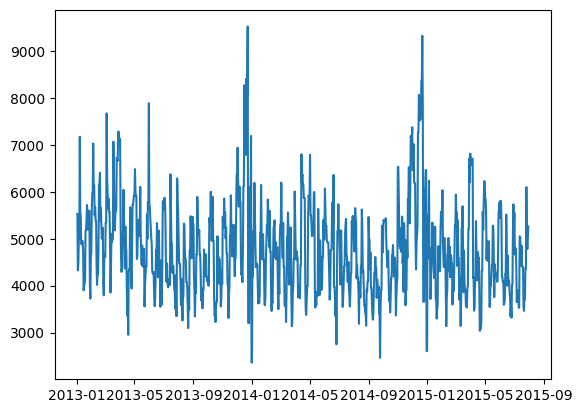

In [8]:
plt.plot(ts)
plt.show()

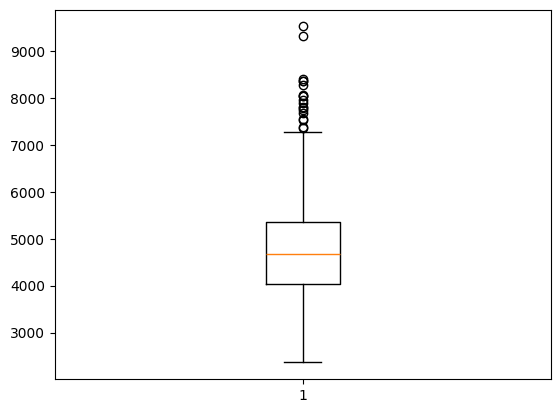

In [9]:
plt.boxplot(ts)
plt.show()

in this we can see that the median is around 4500 and normal range is 3000 to 4000 however there is often outliers it may be due to promotions or discounts days , festivals etc.. so removing it is not an ideal way

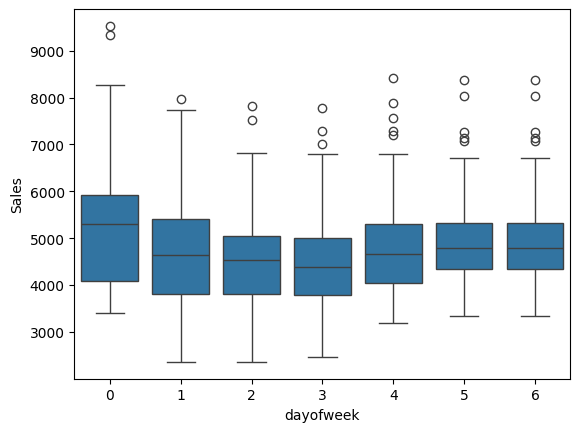

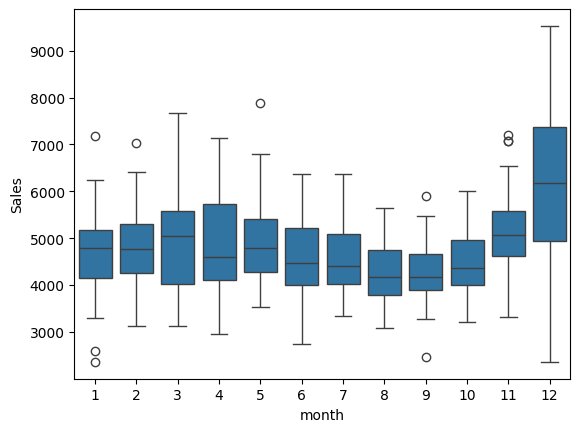

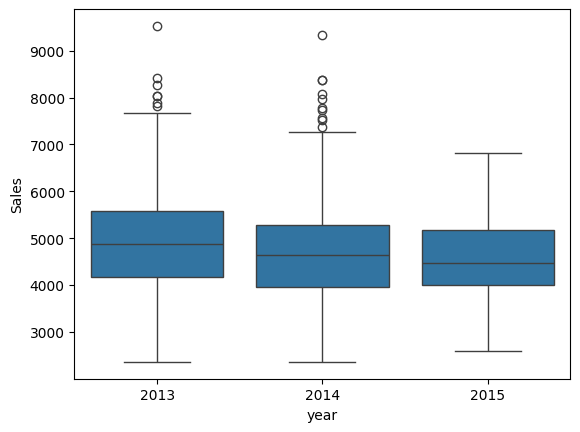

In [10]:
#finding the sales per week, month, year

df_store['dayofweek'] = df_store.index.dayofweek
sns.boxplot(x = 'dayofweek', y = 'Sales', data=df_store)
plt.show()

df_store['month'] = df_store.index.month
sns.boxplot(x = 'month', y = 'Sales', data = df_store)
plt.show()


df_store['year'] = df_store.index.year
sns.boxplot(x = 'year', y = 'Sales', data=df_store)
plt.show()

from the plot we can gather the information that we have strong week seasonality and yearly (for the weekend the sales is increasing and for the end of year the sales is increasing)

## Using different types of models(ARIMA, Exponential Smoothning)

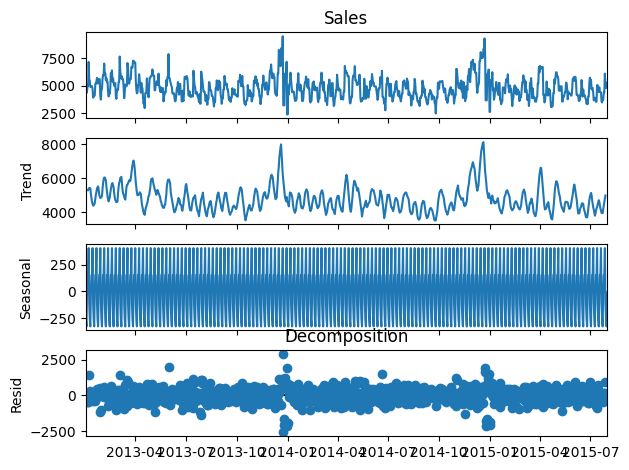

In [11]:
#decomposing the feature to find the trend, seasonality, noise
dec = seasonal_decompose(ts)
dec.plot()
plt.title('Decomposition')
plt.show()

from the graph we can see that there is no certain trend, the feature will be stationary and the variance also doesn't follow certain trends, the residual is concentrated around the 0

In [12]:
#finding whether the feature is stationary or not

stat = adfuller(ts)
if stat[1] > 0.5:
    print(f"p-value :{stat[1]} \n cannot reject null hypothesis :not stationary")
else:
    print(f'p-value: {stat[1]} \n reject null hypothesis: stationary')

p-value: 5.46038906195542e-07 
 reject null hypothesis: stationary


the feature is stationary means : mean, vairance remain constant over time

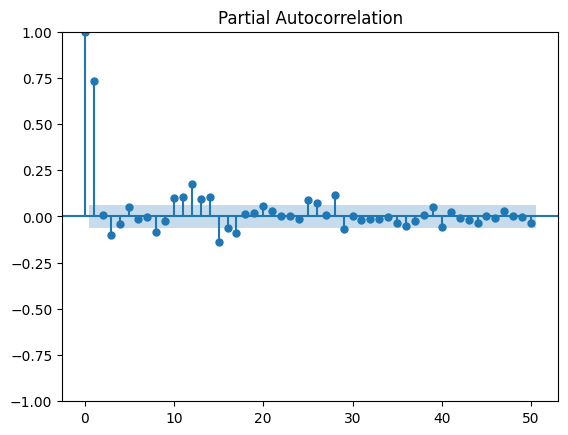

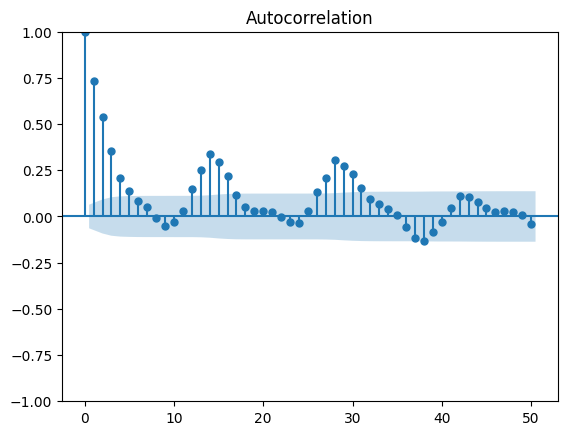

In [13]:
#ploting pacf and acf
plot_pacf(ts,lags=50)
plot_acf(ts,lags=50)
plt.show()


from this we can conclude that the value of p is 1 since there is no other spikes indicating that todays sales is based on yesterday and from the autocorelation map we can find that the values are gradually decreasing the q will be 0 or 1

In [14]:
#splitting the data
size = int(len(ts) * 0.8)
train, test = ts.iloc[:size], ts.iloc[size:]

#taking the log transformation
train_log = np.log(train)

In [15]:
#model fitting
model = ARIMA(train_log, order=(1,0,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))
forecast = np.exp(forecast)

In [16]:
#validating using metrics
print('rmse', root_mean_squared_error(test, forecast))
print('mae', mean_absolute_error(test, forecast))
print('mape', mean_absolute_percentage_error(test, forecast))

rmse 849.3907334484431
mae 703.7383433726434
mape 0.16059628471730678


From the evaluation metrics, the model shows reasonably good performance. The MAE indicates that the average prediction error is around 703 units. The RMSE being higher than the MAE suggests the presence of some larger errors, but not extreme outliers. The MAPE of approximately 16% indicates that the model’s predictions deviate from actual values by about 16% on average.

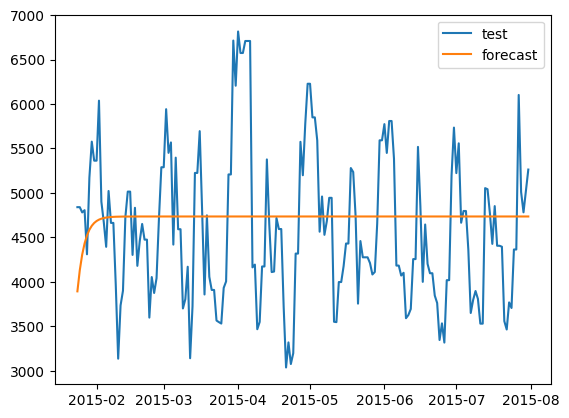

In [17]:
#plotting the actual vs predicted 
plt.plot(test, label = 'test')
plt.plot(forecast, label = 'forecast')
plt.legend()
plt.show()

The model produces a nearly constant prediction and fails to capture the fluctuations and seasonal patterns present in the actual data, indicating that the model is underfitting despite having acceptable error metrics.

# Exponential Smoothining

In [18]:
#simple exponential smoothing
ses = SimpleExpSmoothing(ts).fit()
forecast_ses = ses.forecast(steps = len(test))

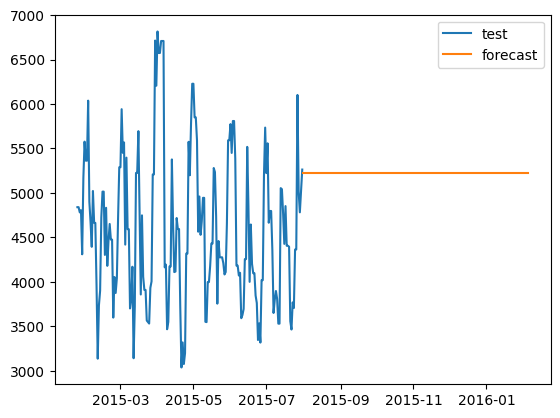

In [19]:
plt.plot(test, label = 'test')
plt.plot(forecast_ses, label = 'forecast')
plt.legend()
plt.show()

In [20]:
print('mae', mean_absolute_error(test, forecast_ses))
print('rmse', root_mean_squared_error(test, forecast_ses))
print('mape', mean_absolute_percentage_error(test, forecast_ses))

mae 886.7090424708593
rmse 1041.133689583726
mape 0.21512649518964527


In [21]:
ho = Holt(ts).fit()
forecast_holt = ho.forecast(len(test))

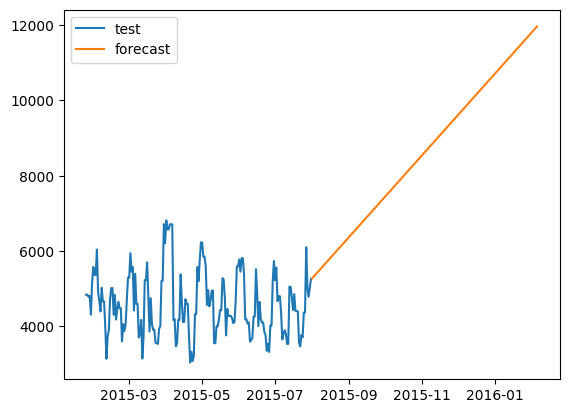

In [22]:
plt.plot(test, label = 'test')
plt.plot(forecast_holt, label = 'forecast')
plt.legend()
plt.show()

In [23]:
print('mae', mean_absolute_error(test, forecast_holt))
print('rmse', root_mean_squared_error(test, forecast_holt))
print('mape', mean_absolute_percentage_error(test, forecast_holt))

mae 4032.1743426931444
rmse 4589.568027288479
mape 0.9464986115509484


In [24]:
trip = ExponentialSmoothing(ts, trend = None, seasonal = 'mul', seasonal_periods = 7).fit()
forecast_trip = trip.forecast(len(test))

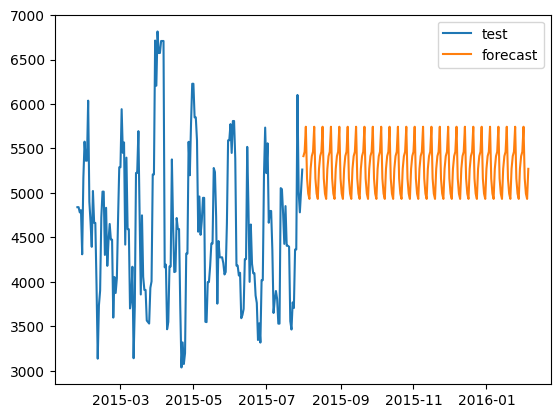

In [25]:
plt.plot(test, label = 'test')
plt.plot(forecast_trip, label = 'forecast')
plt.legend()
plt.show()

In [26]:
print('mae', mean_absolute_error(test, forecast_trip))
print('rmse', root_mean_squared_error(test, forecast_trip))
print('mape', mean_absolute_percentage_error(test, forecast_trip))

mae 906.7730637581205
rmse 1067.8276947304864
mape 0.21973344586935145


# conclusion

among all the ARIMA has lowest MAPE and low mae,rmse but it failed to capture the seasonal pattern, it result in the underfitting since it is predicting in a average level. 

Simple Exponential Smoothing also failed to model trend and seasonality. 

Holt’s method performed poorly by introducing an unrealistic trend. 

Holt-Winters (Triple Exponential Smoothing) captured the seasonal pattern effectively and produced more realistic forecasts, even though its error metrics were slightly higher. Therefore, Holt-Winters is the most appropriate model for this dataset.


Although ARIMA has lower error metrics, it underfits the data. Holt-Winters captures the seasonal pattern and provides more realistic predictions, making it the best model.